# Basic visibility analysis using DEFRA LiDAR

In this example, I'm trying again to use the h3 library to create the hex grids, then use these to calculate the centroids, and then use those for the analysis; possibly this can then also be used for foliage/trees as well.

In [2]:
# Import required libraries
import laspy
import rasterio
from rasterio.transform import from_bounds
from rasterio.mask import mask
from rasterio.merge import merge
from rasterio.io import MemoryFile
from rasterio.warp import calculate_default_transform, reproject, Resampling
from scipy.interpolate import griddata
from scipy.ndimage import generic_filter
import pdal
import json
from pathlib import Path
import datetime

import rasterio
from rasterio.mask import mask
from rasterio.merge import merge
from rasterio.io import MemoryFile

import glob
import os

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point, LineString, Polygon, MultiPolygon
from shapely.ops import unary_union

In [1]:
import h3

## Configuration

Setting up paths, parameters, etc.

Note: generally these will be kept consistent for batch processing, in order to make this more modular (e.g. all LiDAR tiles should be put in the same folder)

In [3]:
park_gdf= gpd.read_file("../../processed_datasets/Leeds_Woodhouse_Moor_park_boundaries.geojson")
lidar_dir= "../../example_datasets"
OUTPUT_DIR = Path("../../outputs/method_04_hex")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Analysis parameters
GRID_SPACING = 10  # meters between analysis points
OBSERVER_HEIGHT = 1.0  # meters (eye height)
MAX_DISTANCE = 100  # maximum visibility distance in meters
MIN_VEG_AREA = 2  # minimum vegetation polygon area in sq meters

FILE_NAME = f"Woodhouse_Moor_{GRID_SPACING}_m_h3"


## CRS + Buffer around park

All analyses use EPSG:27700 (British National Grid) for accurate distance-based calculations (viewshed, intervisibility, grid spacing). Reproject all datasets to this CRS early in the pipeline.


Original park CRS: EPSG:4326
Reprojected park to EPSG:27700
Park boundary CRS: EPSG:27700
Original park area: 219119 m²
Buffered park area: 258752 m²


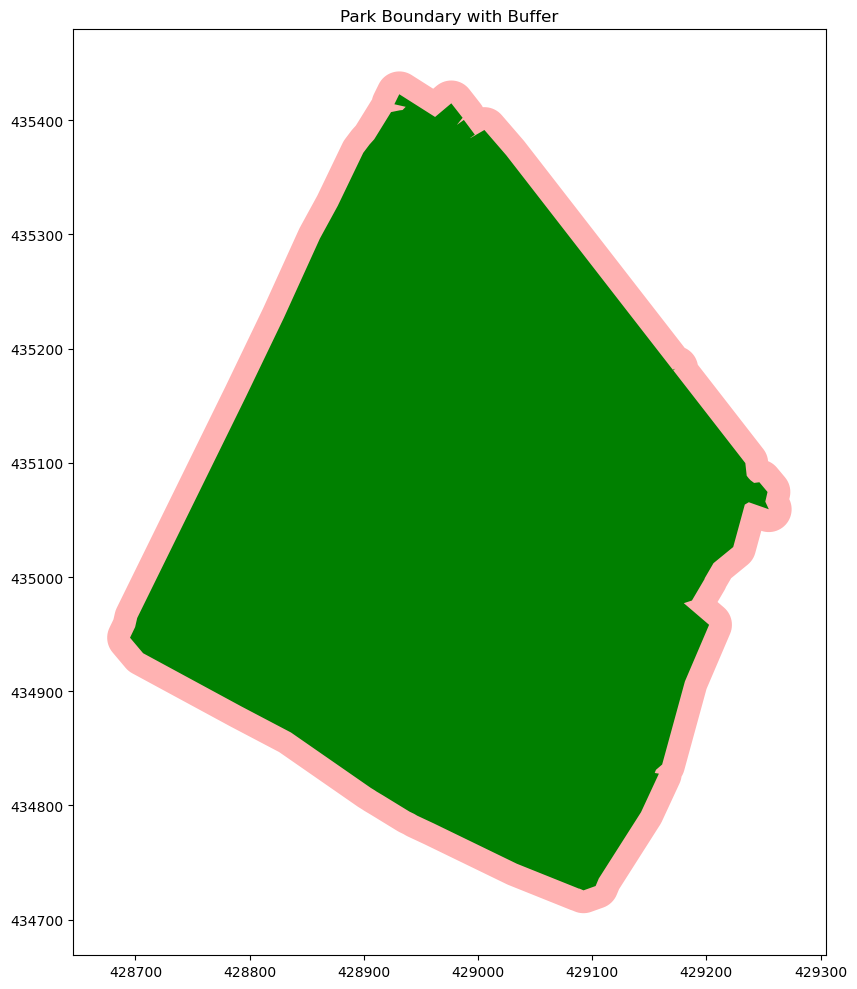

In [4]:
# Normalize CRS to EPSG:27700 (British National Grid)
TARGET_CRS = 'EPSG:27700'

BUFFER_DISTANCE = 20  # meters

print(f"Original park CRS: {park_gdf.crs}")

# Reproject park to target CRS if needed
if park_gdf.crs != TARGET_CRS:
    park_gdf = park_gdf.to_crs(TARGET_CRS)
    print(f"Reprojected park to {TARGET_CRS}")
else:
    print(f"Park already in {TARGET_CRS}")

# Extract park boundary geometry (now in EPSG:27700)
park_boundary = park_gdf.geometry.iloc[0]
print(f"Park boundary CRS: {park_gdf.crs}")

park_boundary_buffered = park_boundary.buffer(BUFFER_DISTANCE)

print(f"Original park area: {park_boundary.area:.0f} m²")
print(f"Buffered park area: {park_boundary_buffered.area:.0f} m²")

fig, ax = plt.subplots(figsize=(12, 10))
gpd.GeoSeries([park_boundary_buffered], crs='EPSG:27700').plot(ax=ax, color='red', alpha=0.3, label='Buffered (+50m)')
gpd.GeoSeries([park_boundary], crs='EPSG:27700').plot(ax=ax, color='green', alpha=1, label='Original park')
ax.set_title('Park Boundary with Buffer')
plt.tight_layout()
plt.show()


# replace the geometry in park_gdf with this new buffered boundary
park_gdf['geometry'] = park_boundary_buffered

Load in the LiDAR data. In this case, all the files we want to work with are present in a single folder; there is no need to filter for grid reference etc.

- Can build in a search functionality for batch processing
    - See previous iteration of this from work Dec 2025 repo

In [5]:
def load_lidar_rasters_for_park(lidar_dir, park_geometry):
    """
    Load and mosaic DSM and DTM rasters from UK National LiDAR Programme
    Handles multiple tiles, CRS mismatches, missing CRS and NoData values
    """
    
    
    # Find DSM and DTM files
    dsm_files = (glob.glob(f"{lidar_dir}/*DSM*.tif") + 
                 glob.glob(f"{lidar_dir}/*dsm*.tif") +
                 glob.glob(f"{lidar_dir}/*FirstReturn*.tif"))
    
    dtm_files = (glob.glob(f"{lidar_dir}/*DTM*.tif") + 
                 glob.glob(f"{lidar_dir}/*dtm*.tif"))
    
    if not dsm_files or not dtm_files:
        print(f"ERROR: Missing files in {lidar_dir}")
        print(f"DSM files found: {len(dsm_files)}")
        print(f"DTM files found: {len(dtm_files)}")
        return None
    
    print(f"Loading {len(dsm_files)} DSM and {len(dtm_files)} DTM files")
    
    # Handle both GeoDataFrame and geometry inputs
    if isinstance(park_geometry, gpd.GeoDataFrame):
        park_gdf = park_geometry.copy()
        park_geom_single = park_geometry.geometry.iloc[0]
    else:
        park_geom_single = park_geometry
        if hasattr(park_geometry, 'crs'):
            park_gdf = gpd.GeoDataFrame([1], geometry=[park_geometry], crs=park_geometry.crs)
        else:
            # Assume WGS84 (lat/lon) if no CRS provided
            park_gdf = gpd.GeoDataFrame([1], geometry=[park_geometry], crs='EPSG:4326')
    
    # Find the raster CRS by checking all files
    raster_crs = None
    for dsm_file in dsm_files:
        with rasterio.open(dsm_file) as src:
            if src.crs is not None:
                raster_crs = src.crs
                break
    
    # If no DSM has CRS, check DTM files
    if raster_crs is None:
        for dtm_file in dtm_files:
            with rasterio.open(dtm_file) as src:
                if src.crs is not None:
                    raster_crs = src.crs
                    break
    
    # If still no CRS found, use park's CRS
    if raster_crs is None:
        raster_crs = park_gdf.crs
        print(f"WARNING: No CRS found in any raster. Assigning park CRS {raster_crs}")
    else:
        # Reproject park if needed
        if park_gdf.crs is not None and park_gdf.crs.to_string() != raster_crs.to_string():
            print(f"Reprojecting park geometry to match raster CRS {raster_crs}")
            park_gdf = park_gdf.to_crs(raster_crs)
            park_geom_single = park_gdf.geometry.iloc[0]
    
    # Function to mosaic multiple rasters with NoData handling
    def mosaic_rasters(file_list, target_crs=None):
        # Use the provided target_crs (from parent function level)
        # If not provided, determine from first raster that has one
        if target_crs is None:
            for f in file_list:
                with rasterio.open(f) as src:
                    if src.crs is not None:
                        target_crs = src.crs
                        break
        
        # If still no CRS found, use the park's CRS
        if target_crs is None:
            target_crs = park_gdf.crs
            print(f"WARNING: No CRS found in rasters. Assigning {target_crs}")
        
        if len(file_list) == 1:
            with rasterio.open(file_list[0]) as src:
                data = src.read(1)
                # Replace NoData values with NaN
                if src.nodata is not None:
                    data = np.where(data == src.nodata, np.nan, data)
                # Also handle extreme values
                data = np.where(data < -1000, np.nan, data)
                # Create output metadata
                out_meta = src.meta.copy()
                if out_meta['crs'] is None:
                    out_meta['crs'] = target_crs
                    print(f"WARNING: {file_list[0]} has no CRS. Assigning {target_crs}")
                return data, src.transform, out_meta
        
        # For multiple files, open and ensure all have CRS
        # Use memory files to normalize CRS before merging
        normalized_files = []
        
        for f in file_list:
            with rasterio.open(f) as src:
                src_crs = src.crs if src.crs is not None else target_crs
                if src.crs is None:
                    print(f"WARNING: {f} has no CRS. Assigning {target_crs}")
                
                # Write to memory file with target CRS
                memfile = MemoryFile()
                out_meta = src.meta.copy()
                out_meta['crs'] = src_crs
                
                with memfile.open(**out_meta) as mem_dst:
                    mem_dst.write(src.read())
                
                # Re-open the memory file
                mem_dst = memfile.open()
                normalized_files.append((mem_dst, memfile))
        
        try:
            # Extract the dataset objects for merging
            src_datasets = [mem_dst for mem_dst, _ in normalized_files]
            
            mosaic, out_transform = merge(src_datasets, nodata=np.nan)
            
            # Clean up NoData values
            mosaic = mosaic[0]
            mosaic = np.where(mosaic < -1000, np.nan, mosaic)
            
            out_meta = src_datasets[0].meta.copy()
            out_meta.update({
                "driver": "GTiff",
                "height": mosaic.shape[0],
                "width": mosaic.shape[1],
                "transform": out_transform,
                "nodata": np.nan,
                "crs": target_crs
            })
            return mosaic, out_transform, out_meta
        finally:
            for mem_dst, memfile in normalized_files:
                mem_dst.close()
                memfile.close()
    
    # Mosaic and clip DSM
    dsm_mosaic, dsm_transform, dsm_meta = mosaic_rasters(dsm_files, target_crs=raster_crs)
    
    # Check for valid data
    valid_dsm = np.sum(~np.isnan(dsm_mosaic))
    print(f"DSM valid pixels: {valid_dsm} of {dsm_mosaic.size} ({valid_dsm/dsm_mosaic.size*100:.1f}%)")
    
    with MemoryFile() as memfile:
        with memfile.open(**dsm_meta) as dataset:
            dataset.write(dsm_mosaic, 1)
            park_geom_list = [park_geom_single.__geo_interface__]
            
            try:
                dsm_clipped, dsm_clip_transform = mask(dataset, park_geom_list, crop=True, nodata=np.nan)
                dsm_clipped = dsm_clipped[0]
            except ValueError as e:
                print(f"ERROR clipping DSM: {e}")
                print(f"Park bounds: {park_gdf.total_bounds}")
                print(f"Park CRS: {park_gdf.crs}, Raster CRS: {raster_crs}")
                return None
    
    # Mosaic and clip DTM
    dtm_mosaic, dtm_transform, dtm_meta = mosaic_rasters(dtm_files, target_crs=raster_crs)
    
    # Check for valid data
    valid_dtm = np.sum(~np.isnan(dtm_mosaic))
    print(f"DTM valid pixels: {valid_dtm} of {dtm_mosaic.size} ({valid_dtm/dtm_mosaic.size*100:.1f}%)")
    
    with MemoryFile() as memfile:
        with memfile.open(**dtm_meta) as dataset:
            dataset.write(dtm_mosaic, 1)
            park_geom_list = [park_geom_single.__geo_interface__]
            dtm_clipped, dtm_clip_transform = mask(dataset, park_geom_list, crop=True, nodata=np.nan)
            dtm_clipped = dtm_clipped[0]
    
    # Calculate height above ground
    height_above_ground = dsm_clipped - dtm_clipped
    
    # Report statistics
    valid_height = ~np.isnan(height_above_ground)
    if np.sum(valid_height) > 0:
        height_range = f"{np.nanmin(height_above_ground):.1f}m to {np.nanmax(height_above_ground):.1f}m"
    else:
        height_range = "No valid data"
    
    print(f"Output shape: {dsm_clipped.shape}, Height range: {height_range}")
    
    # Update metadata for clipped rasters
    dsm_meta.update({
        "height": dsm_clipped.shape[0],
        "width": dsm_clipped.shape[1],
        "transform": dsm_clip_transform,
        "nodata": np.nan
    })
    
    dtm_meta.update({
        "height": dtm_clipped.shape[0],
        "width": dtm_clipped.shape[1],
        "transform": dtm_clip_transform,
        "nodata": np.nan
    })
    
    return {
        'dsm': dsm_clipped,
        'dtm': dtm_clipped,
        'height_above_ground': height_above_ground,
        'dsm_meta': dsm_meta,
        'dtm_meta': dtm_meta,
        'transform': dsm_clip_transform,
        'crs': raster_crs
    }

In [6]:
lidar_data = load_lidar_rasters_for_park(lidar_dir, park_gdf)


Loading 2 DSM and 2 DTM files
DSM valid pixels: 50000000 of 50000000 (100.0%)
DTM valid pixels: 50000000 of 50000000 (100.0%)
Output shape: (738, 600), Height range: -0.6m to 24.5m


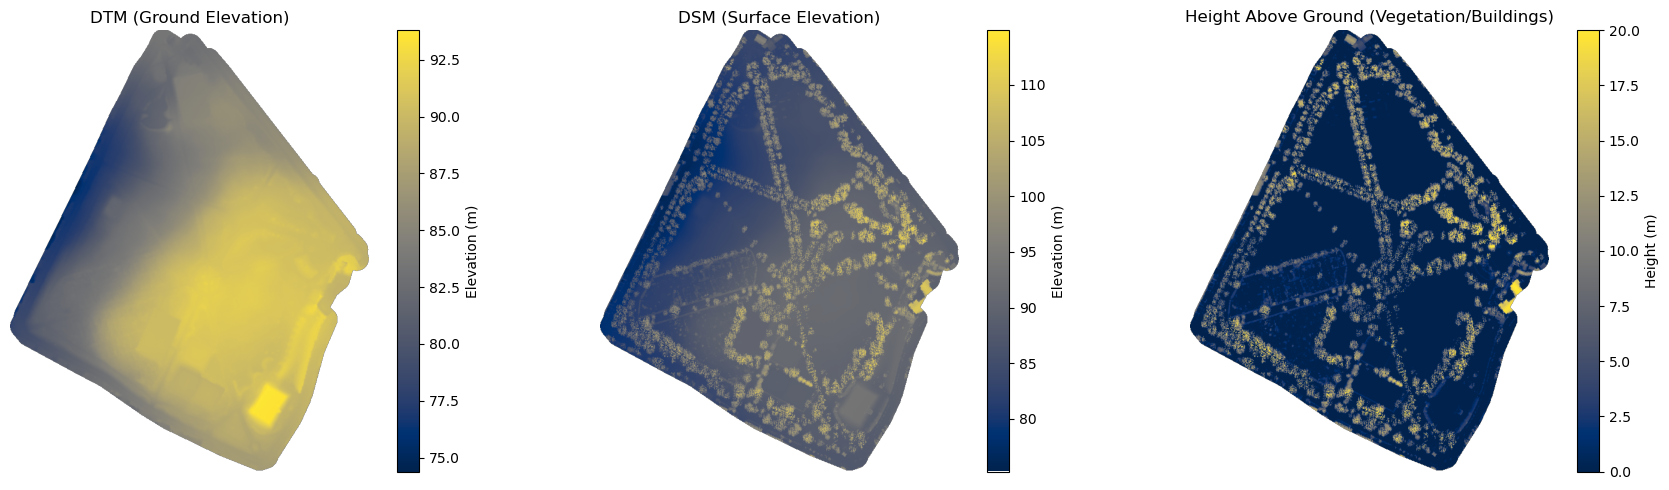

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# DTM
im1 = axes[0].imshow(lidar_data['dtm'], cmap='cividis', origin='upper')
axes[0].set_title('DTM (Ground Elevation)')
plt.colorbar(im1, ax=axes[0], label='Elevation (m)')
axes[0].axis('off')

# DSM
im2 = axes[1].imshow(lidar_data['dsm'], cmap='cividis', origin='upper')
axes[1].set_title('DSM (Surface Elevation)')
plt.colorbar(im2, ax=axes[1], label='Elevation (m)')
axes[1].axis('off')

# Height above ground
im3 = axes[2].imshow(lidar_data['height_above_ground'], 
                     cmap='cividis', origin='upper', vmin=0, vmax=20)
axes[2].set_title('Height Above Ground (Vegetation/Buildings)')
plt.colorbar(im3, ax=axes[2], label='Height (m)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [53]:
def create_hexagon_grid_from_polygons(park_geometry, spacing=10):
    """
    Create hexagonal grid by generating hexagon polygons first,
    then extracting their centroids.
    
    Parameters:
    park_geometry: shapely geometry of park boundary
    spacing: circumradius of each hexagon (distance from center to vertex)
    
    Returns:
    GeoDataFrame with hexagon centroids
    """
    from shapely.geometry import Polygon
    
    bounds = park_geometry.bounds
    
    # Hexagon dimensions
    h_spacing = 1.5 * spacing  # Horizontal spacing
    v_spacing = spacing * np.sqrt(3) / 2  # Vertical spacing
    
    # Create hexagon polygons and collect centroids
    centroids = []
    
    x_min, y_min, x_max, y_max = bounds
    y = y_min
    row = 0
    
    while y <= y_max:
        x = x_min
        if row % 2 == 1:
            x += h_spacing / 2
        
        while x <= x_max:
            # Create hexagon centered at (x, y)
            angles = np.linspace(0, 2*np.pi, 7)
            hex_x = x + spacing * np.cos(angles)
            hex_y = y + spacing * np.sin(angles)
            hexagon = Polygon(list(zip(hex_x, hex_y)))
            
            # Check if hexagon center is in park (or if hexagon intersects)
            if park_geometry.contains(Point(x, y)):
                centroids.append(Point(x, y))
            elif park_geometry.intersects(hexagon):
                # Include if hexagon overlaps park boundary
                centroids.append(Point(x, y))
            
            x += h_spacing
        
        y += v_spacing
        row += 1
    
    grid_gdf = gpd.GeoDataFrame(geometry=centroids, crs='EPSG:27700')
    print(f"Created {len(grid_gdf)} hexagon centers with {spacing}m spacing")
    
    return grid_gdf

In [11]:
def create_h3_centroid_grid(park_geometry, spacing=10):
    """
    Create hexagonal grid using h3 library without polyfill, then extract centroids.
    Works by creating a regular point grid, converting to h3 indices, and filtering.
    
    Parameters:
    park_geometry: shapely geometry of park boundary
    spacing: approximate distance between hexagon centers in meters
    
    Returns:
    GeoDataFrame with hexagon centroids
    """
    # Determine appropriate h3 resolution for desired spacing
    # h3 resolution 7: ~1.2 km edge, res 8: ~0.4 km, res 9: ~0.15 km
    # res 10: ~50 m, res 11: ~15 m, res 12: ~5 m
    if spacing <= 5:
        h3_resolution = 12
    elif spacing <= 10:
        h3_resolution = 11
    elif spacing <= 15:
        h3_resolution = 10
    elif spacing <= 30:
        h3_resolution = 9
    else:
        h3_resolution = 8
    
    print(f"Using H3 resolution {h3_resolution} for spacing of ~{spacing}m")
    
    # Get the bounding box of the park geometry
    minx, miny, maxx, maxy = park_geometry.bounds
    
    # Create a regular grid of points across the bounding box
    # Step size in degrees (rough approximation: 1 degree ≈ 111km, so 10m ≈ 0.0001 degrees)
    step_size = spacing / 111000  # Convert meters to degrees
    
    h3_indices = set()
    
    # Create grid of points and convert each to h3 index
    y = miny
    while y <= maxy:
        x = minx
        while x <= maxx:
            try:
                # Convert lat/lon to h3 index
                h3_index = h3.geo_to_h3(y, x, h3_resolution)
                h3_indices.add(h3_index)
            except:
                pass
            x += step_size
        y += step_size
    
    # Convert h3 indices to centroids and filter by park geometry
    centroids = []
    h3_polygons = []
    
    for hex_id in h3_indices:
        try:
            # Get the geo boundary (lat/lon) of the hexagon
            hex_boundary_latlon = h3.h3_to_geo_boundary(hex_id, geo_json=True)
            
            # Convert from lat/lon to x/y (swap coordinates for shapely)
            hex_boundary_xy = [(lon, lat) for lat, lon in hex_boundary_latlon]
            hex_polygon = Polygon(hex_boundary_xy)
            
            # Get centroid
            centroid = hex_polygon.centroid
            
            # Check if centroid is in park or hexagon intersects park
            if park_geometry.contains(centroid) or park_geometry.intersects(hex_polygon):
                centroids.append(centroid)
                h3_polygons.append(hex_polygon)
        except:
            pass
    
    grid_gdf = gpd.GeoDataFrame(
        {'geometry': centroids},
        crs='EPSG:27700'
    )
    
    print(f"Created {len(grid_gdf)} H3 hexagon centers")
    print(f"H3 resolution: {h3_resolution}, Bounds: {minx}, {miny}, {maxx}, {maxy}")
    
    return grid_gdf

In [12]:
# Create analysis grid
# Park boundary is now guaranteed to be in EPSG:27700
# square grid spacing: "Created 2185 analysis points with 10m spacing"
# hex: "Created 1685 analysis points with hexagonal spacing (~10m to nearest neighbors)"
# new hex: "Created 1821 hexagon centers with 10m spacing"
# with 20m buffer around the edge: Created 2136 hexagon centers with 10m spacing
analysis_points = create_h3_centroid_grid(park_boundary_buffered, spacing=GRID_SPACING)


Using H3 resolution 11 for spacing of ~10m


KeyboardInterrupt: 

Ok, this is taking way too much time - abandoning this. Possibly something for a future workflow? Currently don't think it brings appropriate benefits for the development cost.

If all LiDAR analysis work uses the same generated grid consistently, then I think this is fine.